In [12]:
import pandas as pd

def create_meta_dataset(whisper_csv, mms_csv, xlsr_csv, output_csv):
    print(f"Merging files into {output_csv}...")
    
    df_whisper = pd.read_csv(whisper_csv)
    df_mms = pd.read_csv(mms_csv)
    df_xlsr = pd.read_csv(xlsr_csv)
    
    df_mms = df_mms[['segment_id', 'start_time', 'end_time', 'mms_prob_hin']]
    df_xlsr = df_xlsr[['segment_id', 'start_time', 'end_time', 'xlsr_prob_hin']]
    
    merge_cols = ['segment_id', 'start_time', 'end_time']
    meta_df = pd.merge(df_whisper, df_mms, on=merge_cols, how='inner')
    meta_df = pd.merge(meta_df, df_xlsr, on=merge_cols, how='inner')
    
    meta_df['duration_sec'] = meta_df['end_time'] - meta_df['start_time']
    
    label_map = {'eng': 0, 'hin': 1}
    meta_df['true_label'] = meta_df['label'].map(label_map)
    
    final_features = [
        'segment_id', 'start_time', 'end_time', 'duration_sec', 
        'whisper_prob_hin', 'mms_prob_hin', 'xlsr_prob_hin', 
        'true_label'
    ]
    meta_df = meta_df[final_features]
    
    meta_df = meta_df.drop_duplicates()
    
    meta_df.to_csv(output_csv, index=False)
    print(f"Successfully generated Meta-Dataset with {len(meta_df)} rows!")

create_meta_dataset(
    '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/whisper_val_probs.csv', 
    '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/mms_val_probs.csv', 
    '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/xlsr_val_probs.csv', 
    '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/meta_features_validation.csv'
)
create_meta_dataset(
    '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/whisper_test_probs.csv', 
    '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/mms_test_probs.csv', 
    '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/xlsr_test_probs.csv', 
    '/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/meta_features_test.csv'
)

Merging files into /media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/meta_features_validation.csv...
Successfully generated Meta-Dataset with 5108 rows!
Merging files into /media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/meta_features_test.csv...
Successfully generated Meta-Dataset with 9971 rows!


In [13]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

val_df = pd.read_csv('/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/meta_features_validation.csv')
test_df = pd.read_csv('/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/meta_features_test.csv')

features = ['whisper_prob_hin', 'mms_prob_hin', 'xlsr_prob_hin', 'duration_sec']

X_val = val_df[features]
y_val = val_df['true_label']

X_test = test_df[features]
y_test = test_df['true_label']

meta_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42
)

print("Training Meta-Classifier...")
meta_model.fit(X_val, y_val)

print("Making Final Ensemble Predictions...")
meta_preds = meta_model.predict(X_test)

final_acc = accuracy_score(y_test, meta_preds)
print(f"\n FINAL META-ENSEMBLE ACCURACY: {final_acc * 100:.2f}% \n")

print("Classification Report:")
print(classification_report(y_test, meta_preds, target_names=["English", "Hindi"]))

print("\nFeature Importances (What the Meta-Model cares about):")
for feature, importance in zip(features, meta_model.feature_importances_):
    print(f"{feature}: {importance:.4f}")

Training Meta-Classifier...
Making Final Ensemble Predictions...

 FINAL META-ENSEMBLE ACCURACY: 93.14% 

Classification Report:
              precision    recall  f1-score   support

     English       0.94      0.88      0.91      3970
       Hindi       0.93      0.96      0.94      6001

    accuracy                           0.93      9971
   macro avg       0.93      0.92      0.93      9971
weighted avg       0.93      0.93      0.93      9971


Feature Importances (What the Meta-Model cares about):
whisper_prob_hin: 0.0516
mms_prob_hin: 0.4343
xlsr_prob_hin: 0.4945
duration_sec: 0.0196


In [24]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

val_df = pd.read_csv('/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/meta_features_validation.csv')
test_df = pd.read_csv('/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/meta_features_test.csv')

features = ['whisper_prob_hin', 'mms_prob_hin', 'xlsr_prob_hin', 'duration_sec']

X_val = val_df[features]
y_val = val_df['true_label']

X_test = test_df[features]
y_test = test_df['true_label']

meta_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.06,
    eval_metric='logloss',
    random_state=42
)

print("Training Meta-Classifier...")
meta_model.fit(X_val, y_val)

print("Making Final Ensemble Predictions...")
meta_preds = meta_model.predict(X_test)

final_acc = accuracy_score(y_test, meta_preds)
print(f"\n FINAL META-ENSEMBLE ACCURACY: {final_acc * 100:.2f}% \n")

print("Classification Report:")
print(classification_report(y_test, meta_preds, target_names=["English", "Hindi"]))

print("\nFeature Importances (What the Meta-Model cares about):")
for feature, importance in zip(features, meta_model.feature_importances_):
    print(f"{feature}: {importance:.4f}")

Training Meta-Classifier...
Making Final Ensemble Predictions...

 FINAL META-ENSEMBLE ACCURACY: 93.15% 

Classification Report:
              precision    recall  f1-score   support

     English       0.94      0.88      0.91      3970
       Hindi       0.93      0.96      0.94      6001

    accuracy                           0.93      9971
   macro avg       0.93      0.92      0.93      9971
weighted avg       0.93      0.93      0.93      9971


Feature Importances (What the Meta-Model cares about):
whisper_prob_hin: 0.0573
mms_prob_hin: 0.4357
xlsr_prob_hin: 0.4881
duration_sec: 0.0190


<Figure size 800x600 with 0 Axes>

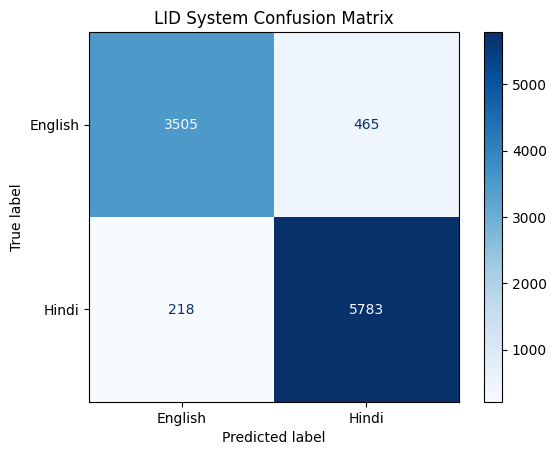

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['English', 'Hindi']

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(y_test, meta_preds, display_labels=class_names, cmap='Blues')
plt.title('LID System Confusion Matrix')
plt.show()

In [26]:
import pandas as pd

test_df = pd.read_csv('/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/new/probability/meta_features_test.csv')
original_test = pd.read_csv('/media/nit/DATADRIVE1/AJAY/MLproject/LID_MAIN/labeled/labeled_word_timings_test.csv')

test_df['predicted_label'] = meta_preds
errors_df = test_df[test_df['true_label'] != test_df['predicted_label']].copy()


rev_label_map = {0: 'eng', 1: 'hin'}
errors_df['true_label'] = errors_df['true_label'].map(rev_label_map)
errors_df['predicted_label'] = errors_df['predicted_label'].map(rev_label_map)

merge_cols = ['segment_id', 'start_time', 'end_time']
errors_df = pd.merge(
    errors_df, 
    original_test[['segment_id', 'start_time', 'end_time', 'ref_word']], 
    on=merge_cols, 
    how='left'
)

errors_df = errors_df.drop_duplicates()

errors_df.to_csv('final_meta_errors_clean.csv', index=False)
print(f" Successfully isolated the true {len(errors_df)} errors! ")

print("\nTop 15 Most Frequent Mistakes:")
top_mistakes = errors_df.groupby(['ref_word', 'true_label', 'predicted_label']).size().reset_index(name='count')
print(top_mistakes.sort_values(by='count', ascending=False).head(15))

 Successfully isolated the true 683 errors! 

Top 15 Most Frequent Mistakes:
    ref_word true_label predicted_label  count
135      the        eng             hin     24
83        is        eng             hin     17
43       are        eng             hin     11
178       इस        hin             eng     11
114       or        eng             hin     10
257       है        hin             eng      9
166      you        eng             hin      9
208       तो        hin             eng      8
41       and        eng             hin      8
72        he        eng             hin      7
187       और        hin             eng      7
92      like        eng             hin      6
111       of        eng             hin      6
157       we        eng             hin      6
145       to        eng             hin      6
